← [Conceptos clave](13-conceptos-clave.ipynb) · [Índice](00-indice.ipynb)

# 14 · Conexiones físicas del sistema

Toda la serie anterior trata de cómo Reci **decide**. Este documento trata de
cómo esa decisión se convierte en una compuerta que se abre.

> Para ensamblar, la referencia operativa es
> [`docs/CONEXIONES.md`](../CONEXIONES.md), pensada para imprimir y tener al
> lado. Aquí se explica **por qué** el sistema está conectado así.

---



## Estado vigente del cableado (actualizado el 13 de agosto de 2026)

El sketch integrado usa **Serial2**, no Serial2: ESP32 GPIO14/TX va directo al Mega D17/RX2; Mega D16/TX2 llega al ESP32 GPIO13/RX mediante divisor 1 kΩ / 2 kΩ. La orden vigente es `CMD:CLASSIFY:vidrio|plastico`; ante `desconocido` o una respuesta incompleta no se envía ninguna orden.

La referencia operativa es [`firmware/esp32-cam/README.md`](../../firmware/esp32-cam/README.md) y `ReciRutaDemo.ino`.


## La cadena completa

```
   persona            ┌──────────────┐
   acerca un   ────→  │  ESP32-CAM   │  captura 3 fotos
   residuo            │  (OV3660)    │
                      └──────┬───────┘
                             │ HTTPS sobre WiFi
                      ┌──────▼───────┐
                      │  Next.js API │  autenticación del robot
                      └──────┬───────┘
                             │ HTTP interno
                      ┌──────▼───────────────┐
                      │ Servicio de visión   │  proveedor + experto + CNN
                      └──────┬───────────────┘
                             │ { material, confidence }
                      ┌──────▼───────┐
                      │  ESP32-CAM   │
                      └──────┬───────┘
                             │ Serial TX/RX  ── CMD:CLASSIFY:vidrio
                      ┌──────▼──────────┐
                      │ Arduino Mega    │  controlador central
                      └──────┬──────────┘
                             │ PWM
                      ┌──────▼───────┐
                      │    Servo     │  abre la compuerta
                      └──────────────┘
```

Dos controladores con papeles distintos:

| | ESP32-CAM | Arduino Mega 2560 |
| --- | --- | --- |
| Papel | Ojos y red | Cuerpo y actuadores |
| Hace | Capturar, enviar por WiFi, recibir el veredicto | Motores, servos, sensores, pantalla |
| No hace | Mover nada | Hablar con Internet |

La división existe porque el Mega no tiene WiFi ni cámara, y el ESP32-CAM tiene
pocos pines libres. Cada uno hace lo que su hardware permite.

---

## Las tres reglas eléctricas que no se rompen

### 1. Todas las tierras van unidas

```
GND LiPo ── GND Mega ── GND L298N#1 ── GND L298N#2 ── GND ESP32 ── GND sensores
```

Un voltaje es siempre una **diferencia** entre dos puntos. Si dos módulos no
comparten referencia, "5 V" en uno no significa lo mismo que en el otro, y la
comunicación serial falla de forma intermitente — el peor tipo de fallo, porque
parece un problema de software.

### 2. El ESP32-CAM es de 3,3 V

Sus pines **no toleran 5 V**. El Arduino Mega transmite a 5 V, así que la línea
`TX2 del Mega → GPIO13 del ESP32` necesita un **divisor de voltaje** que la baje
a ~3,3 V.

```
Mega TX2 (pin 18) ──[ R1 ]──┬──[ R2 ]── GND
                            │
                            └──→ ESP32 GPIO13  (~3,3 V)
```

La dirección contraria no lo necesita: el ESP32 transmite a 3,3 V y el Mega lo
lee como nivel alto sin problema. **El divisor es obligatorio y va en un solo
sentido.**

### 3. Los motores y la electrónica no comparten fuente

| Fuente | Alimenta |
| --- | --- |
| LiPo 7,4 V | Motores (L298N ×2) y el Mega por VIN |
| Power Bank 10 Ah | Electrónica sensible |
| LM2596 (7,4 V → 5,0 V) | ESP32-CAM |

Un motor al arrancar consume un pico de corriente que hunde el voltaje de la
línea. Si el ESP32 comparte esa línea, se reinicia justo cuando el robot empieza
a moverse. Por eso los motores van por su lado y el LM2596 entrega 5 V estables
—hay que ajustarlo con su potenciómetro **antes** de conectar el ESP32.

---



## Mapa de pines relevante del Arduino Mega

El sketch integrado usa **Serial2 para la ESP32-CAM**.

| Pines | Componente | Función |
| --- | --- | --- |
| 2–13 | L298N y motores | Movimiento, según `ReciRutaDemo.ino` |
| **16, 17** | **ESP32-CAM** | **D16/TX2 → GPIO13 (divisor); D17/RX2 ← GPIO14** |
| 20, 21 | Bus I2C | OLED y periféricos I2C |
| 22–28 | Sensores | Ultrasonidos y PIR |
| 44, 45 | Servos | Compuertas de plástico y vidrio |


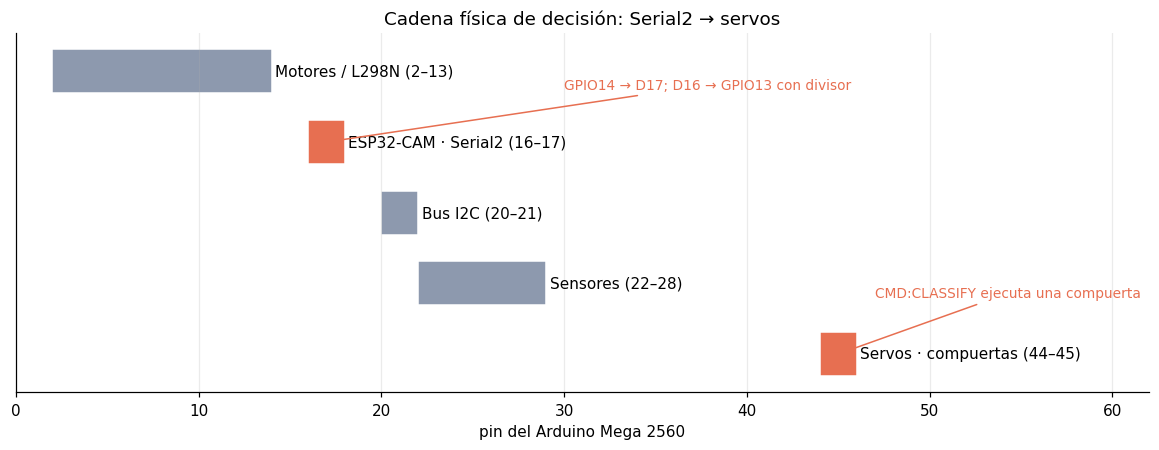

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

VIDRIO, PLASTICO, GRIS, ALERTA = '#2a9d8f', '#e9c46a', '#8d99ae', '#e76f51'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False})
fig, ax = plt.subplots(figsize=(11, 4.2))
bloques = [('Motores / L298N', 2, 13, GRIS), ('ESP32-CAM · Serial2', 16, 17, ALERTA), ('Bus I2C', 20, 21, GRIS), ('Sensores', 22, 28, GRIS), ('Servos · compuertas', 44, 45, ALERTA)]
for i, (nombre, inicio, fin, color) in enumerate(bloques):
    ax.barh(i, fin - inicio + 1, left=inicio, height=.62, color=color, edgecolor='white')
    ax.text(fin + 1.2, i, f'{nombre} ({inicio}–{fin})', va='center', fontsize=10)
ax.set_yticks([]); ax.set_xlabel('pin del Arduino Mega 2560'); ax.set(xlim=(0, 62), title='Cadena física de decisión: Serial2 → servos'); ax.invert_yaxis(); ax.grid(axis='x', alpha=.25)
ax.annotate('GPIO14 → D17; D16 → GPIO13 con divisor', xy=(17, 1), xytext=(30, .25), arrowprops=dict(arrowstyle='->', color=ALERTA), color=ALERTA, fontsize=9)
ax.annotate('CMD:CLASSIFY ejecuta una compuerta', xy=(45, 4), xytext=(47, 3.2), arrowprops=dict(arrowstyle='->', color=ALERTA), color=ALERTA, fontsize=9)
plt.tight_layout(); plt.show()


## El ESP32-CAM

| Pin | Conexión |
| --- | --- |
| 5V | Power Bank o regulador de 5 V estable |
| GND | GND común |
| GPIO14 (TX) | → Mega RX2 / D17 — directo |
| GPIO13 (RX) | ← Mega TX2 / D16 — **con divisor 5 V → 3,3 V** |
| GPIO0 | → GND solo para programar; quitar después |


## El protocolo entre los dos controladores

Solo una decisión final válida envía una línea al Mega:

```
CMD:CLASSIFY:vidrio
CMD:CLASSIFY:plastico
```

Con `desconocido`, una respuesta incompleta o un error de servicio no se envía `CMD:CLASSIFY`; ningún servo se mueve.


## Orden de ensamble

Nunca todo a la vez. Cada etapa se prueba antes de la siguiente:

```
1. Energía y tierra común        5. Sensores (ultrasonidos + PIR)
2. Arduino Mega solo             6. OLED + MPU (I2C)
3. Motores + L298N               7. ESP32-CAM
4. Servomotores                  8. Prueba integrada
```

La razón es diagnóstica: si se conecta todo y algo falla, hay decenas de
causas posibles. Añadiendo una etapa a la vez, el culpable es siempre lo último
que se tocó.

---



## Dónde encaja el modelo

Vale la pena cerrar la serie situando las 18.029 imágenes, las 193 reglas y las
nueve corridas de entrenamiento:

```
todo eso  →  produce  →  una cadena de texto de 16 caracteres
                          CMD:CLASSIFY:vidrio
                             ↓
                          un servo gira ~90°
```

Ese es el producto final. Y explica por qué el proyecto prefiere abstenerse:
el resto del sistema —red, servicio, votación— puede reintentar, pero un servo
que se movió ya movió.

---

← [Conceptos clave](13-conceptos-clave.ipynb) · [Índice](00-indice.ipynb)